<a href="https://colab.research.google.com/github/abhirupchak/Wheat-Yield-Regression-Analysis-FAOSTAT/blob/main/iris_decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving 07_loan_approval.csv to 07_loan_approval (1).csv
Dataset Shape: (600, 11)

First 5 rows:
  ApplicantID  Age  AnnualIncome  LoanAmount  CreditScore  EmploymentYears  \
0       L0001   25         35200       30000          703              7.4   
1       L0002   55         38300      133000          712              2.1   
2       L0003   50         35800       95000          678             10.9   
3       L0004   40         43000      103000          694              5.2   
4       L0005   40         77800       84000          728              3.4   

      Education MaritalStatus PropertyArea SelfEmployed LoanApproved  
0      Graduate       Married        Rural           No            Y  
1      Graduate       Married        Urban           No            N  
2      Graduate       Married    Semiurban          Yes            Y  
3      Graduate       Married    Semiurban           No            N  
4  Not Graduate      Divorced        Urban           No            N  

Features

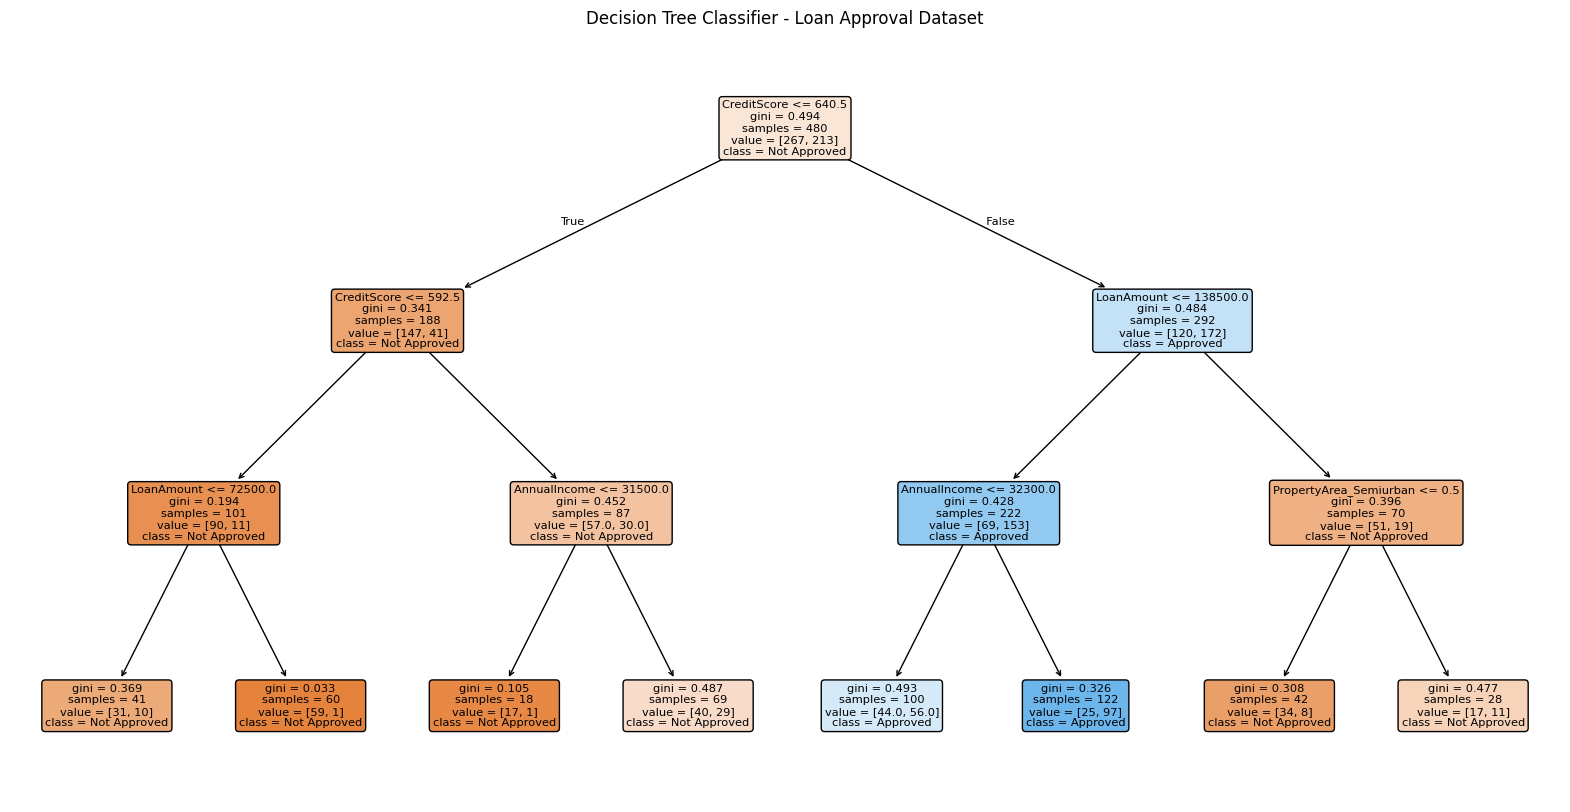

In [ ]:
# Loan Approval Classification using Decision Tree

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
# 1. Upload dataset
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# 2. Load dataset
df = pd.read_csv(file_name)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())


# ---------------------------------------------------
# 2. Separate Features and Target
# ---------------------------------------------------

# ApplicantID is only an identifier, so we don't use it
X = df.drop(columns=["ApplicantID", "LoanApproved"])

y = df["LoanApproved"]


# Convert target Y/N into 1/0
y = y.map({
    "N": 0,
    "Y": 1
})


# ---------------------------------------------------
# 3. Convert Categorical Features into Dummy Variables
# ---------------------------------------------------

X = pd.get_dummies(
    X,
    drop_first=True
)

print("\nFeatures after encoding:")
print(X.columns)


# ---------------------------------------------------
# 4. Split Dataset - 80% Training, 20% Testing
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    train_size=0.80,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------
# 5. Create Decision Tree Model
# ---------------------------------------------------

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)


# ---------------------------------------------------
# 6. Train Model
# ---------------------------------------------------

model.fit(X_train, y_train)


# ---------------------------------------------------
# 7. Make Predictions
# ---------------------------------------------------

y_pred = model.predict(X_test)

# Probability of LoanApproved = Y
y_prob = model.predict_proba(X_test)[:, 1]


# ---------------------------------------------------
# 8. Calculate Accuracy
# ---------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n========== ACCURACY ==========")
print("Accuracy:", accuracy)


# ---------------------------------------------------
# 9. Calculate Precision
# ---------------------------------------------------

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print("\n========== PRECISION ==========")
print("Precision:", precision)


# ---------------------------------------------------
# 10. Calculate Recall
# ---------------------------------------------------

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

print("\n========== RECALL ==========")
print("Recall:", recall)


# ---------------------------------------------------
# 11. Calculate F1 Score
# ---------------------------------------------------

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("\n========== F1 SCORE ==========")
print("F1 Score:", f1)


# ---------------------------------------------------
# 12. Calculate Support
# ---------------------------------------------------

support_N = sum(y_test == 0)
support_Y = sum(y_test == 1)

print("\n========== SUPPORT ==========")
print("N (Not Approved):", support_N)
print("Y (Approved):", support_Y)


# ---------------------------------------------------
# 13. Precision, Recall and F1 Score for Each Class
# ---------------------------------------------------

precision_per_class = precision_score(
    y_test,
    y_pred,
    average=None
)

recall_per_class = recall_score(
    y_test,
    y_pred,
    average=None
)

f1_per_class = f1_score(
    y_test,
    y_pred,
    average=None
)

print("\n========== CLASS-WISE METRICS ==========")

class_names = ["Not Approved", "Approved"]

for i in range(2):

    if i == 0:
        support = support_N
    else:
        support = support_Y

    print("\nClass:", class_names[i])
    print("Precision:", precision_per_class[i])
    print("Recall:", recall_per_class[i])
    print("F1 Score:", f1_per_class[i])
    print("Support:", support)


# ---------------------------------------------------
# 14. Confusion Matrix
# ---------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n========== CONFUSION MATRIX ==========")
print(cm)


# ---------------------------------------------------
# 15. Calculate AUC
# ---------------------------------------------------

auc = roc_auc_score(
    y_test,
    y_prob
)

print("\n========== AUC ==========")
print("AUC:", auc)


# ---------------------------------------------------
# 17. Visualize Decision Tree
# ---------------------------------------------------

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Approved", "Approved"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree Classifier - Loan Approval Dataset")
plt.show()